# Disaster Tweet Classifier — 03. Interpretability & Error Analysis

**Model:** `NB_optuna` — MultinomialNB (`alpha=0.7255`, `fit_prior=False`)  
**Pipeline:** TF-IDF (unigrams + bigrams, max 10k) → Multinomial Naive Bayes  
**Performance:** F1-val = 0.8003 · F1-test = 0.7624  
**Test confusion matrix:** 1 227 TN · 216 TP · 162 FP · 101 FN  

---

**Sections**  
0. Setup & Imports  
1. Model Recap  
2. Error Analysis  
3. Global Interpretability — SHAP  
4. Local Interpretability — LIME  
5. Robustness  
6. Synthesis & Recommendations  


## 0. Setup & Imports

### Description de l'étape

Install optional dependencies (SHAP, LIME, kaleido), centralise all imports,
load the serialised model artifact, load the three data splits, generate
predictions on the test set, and cross-check embedded metrics.


In [1]:
import subprocess
import sys

for _pkg in ['shap', 'lime', 'kaleido']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', _pkg, '-q'],
                   capture_output=True, check=False)
print('Extra dependencies ready.')


Extra dependencies ready.


In [2]:
import os
import sys
import warnings

import dill
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import scipy.sparse as sp
import shap
from IPython.display import display
from lime.lime_text import LimeTextExplainer
from loguru import logger
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

COLOR_NOT_DISASTER = '#1f77b4'
COLOR_DISASTER     = '#d62728'
COLORS = [COLOR_NOT_DISASTER, COLOR_DISASTER]
LABELS = ['Not Disaster (0)', 'Real Disaster (1)']

FIG_DIR = '../reports/figures'
os.makedirs(FIG_DIR, exist_ok=True)

logger.info('Imports complete.')


c:\Users\BachirTraore\.conda\envs\envtp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-10 01:05:19.758 | INFO     | __main__:<module>:39 - Imports complete.


In [3]:
with open('../models/NB_optuna.pkl', 'rb') as _f:
    artifact = dill.load(_f)

model      = artifact['model']
tfidf      = artifact['tfidf']
scaler     = artifact['scaler']
model_name = artifact['model_name']
features   = artifact['features']
f1_val     = artifact['f1_val']
f1_test    = artifact['f1_test']

train = pd.read_parquet('../data/processed/train.parquet')
val   = pd.read_parquet('../data/processed/val.parquet')
test  = pd.read_parquet('../data/processed/test.parquet')

X_test_tfidf = tfidf.transform(test['preprocessed_text'])
y_test       = test['target'].values
y_pred       = model.predict(X_test_tfidf)
y_proba      = model.predict_proba(X_test_tfidf)[:, 1]

test = test.copy()
test['y_pred']     = y_pred
test['y_proba']    = y_proba
test['error_type'] = 'TN'
test.loc[(test['target'] == 1) & (test['y_pred'] == 1), 'error_type'] = 'TP'
test.loc[(test['target'] == 1) & (test['y_pred'] == 0), 'error_type'] = 'FN'
test.loc[(test['target'] == 0) & (test['y_pred'] == 1), 'error_type'] = 'FP'

err_counts = dict(test['error_type'].value_counts())
logger.info(f'Model : {model_name}  |  F1-val={f1_val:.4f}  |  F1-test={f1_test:.4f}')
logger.info(f'Test  : {len(test)} samples  |  {int(test["target"].sum())} disasters')
logger.info(f'Error breakdown — {err_counts}')


2026-06-10 01:08:43.541 | INFO     | __main__:<module>:30 - Model : NB_optuna  |  F1-val=0.8003  |  F1-test=0.7624
2026-06-10 01:08:43.544 | INFO     | __main__:<module>:31 - Test  : 1706 samples  |  317 disasters
2026-06-10 01:08:43.544 | INFO     | __main__:<module>:32 - Error breakdown — {'TN': np.int64(1227), 'TP': np.int64(216), 'FP': np.int64(162), 'FN': np.int64(101)}


In [4]:
f1_recomputed = f1_score(y_test, y_pred, average='macro')
assert abs(f1_recomputed - f1_test) < 0.01, (
    f'F1 mismatch: recomputed={f1_recomputed:.4f} vs embedded={f1_test:.4f}'
)

metrics_df = pd.DataFrame({
    'Metric': ['F1-macro', 'F1-weighted', 'ROC-AUC', 'Precision-macro', 'Recall-macro'],
    'Value': [
        f1_recomputed,
        f1_score(y_test, y_pred, average='weighted'),
        roc_auc_score(y_test, y_proba),
        precision_score(y_test, y_pred, average='macro'),
        recall_score(y_test, y_pred, average='macro'),
    ]
}).assign(Value=lambda df: df['Value'].round(4))

display(metrics_df.style.background_gradient(subset=['Value'], cmap='Blues'))


,Metric,Value
0,F1-macro,0.762400
1,F1-weighted,0.850900
2,ROC-AUC,0.872700
3,Precision-macro,0.747700
4,Recall-macro,0.782400


### Analyse & Interprétation — Section 0

- Artifact loaded correctly; embedded F1-test matches the recomputed value (delta < 0.01).
- The test set contains **1 706 samples** with a moderate class imbalance (~18.6 % disaster).
- ROC-AUC above 0.83 confirms the model ranks disasters well even before threshold tuning.
- Figures will be saved to `reports/figures/` for traceability.


---
## 1. Model Recap

### Description de l'étape

Reference point for the entire notebook.  
All interpretability results below must be read in the context of this pipeline.

| Property | Value |
|---|---|
| Algorithm | Multinomial Naive Bayes |
| Hyperparameters | `alpha=0.7255`, `fit_prior=False` |
| Vectoriser | TF-IDF, unigrams + bigrams, max 10 000 features, `sublinear_tf=True` |
| Input | `preprocessed_text` (stemmed, stop-words removed) — **TF-IDF only, no numeric features** |
| Optimisation | Optuna, 30 trials (NB/LR/SGD/LinearSVC) + 50 trials (XGBoost), primary metric F1-macro |
| F1-val | 0.8003 |
| F1-test | 0.7624 |
| Test confusion | TN=1227 · TP=216 · FP=162 · FN=101 |

**Key constraint for interpretability:**  
Because the model is a Naive Bayes classifier, its log-posterior is linear in TF-IDF feature values.
SHAP attributions therefore correspond directly to the per-token log-likelihood contributions.
LIME treats the pipeline as a black box and is model-agnostic.


---
## 2. Error Analysis

### Description de l'étape

Four complementary lenses on the model's mistakes:
1. Enriched confusion matrix with per-cell rates and business framing.
2. Predicted-probability distributions — identify the uncertainty zone.
3. Top-20 False Negatives (missed disasters): text patterns and shared keywords.
4. Top-20 False Positives (false alarms): same analysis.
5. Error rate by keyword — cross-reference with ambiguous keywords from EDA.


In [5]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
total = len(y_test)

cm_text = [
    [f'TN = {tn}<br>({tn/total:.1%})', f'FP = {fp}<br>({fp/total:.1%})'],
    [f'FN = {fn}<br>({fn/total:.1%})', f'TP = {tp}<br>({tp/total:.1%})']
]

fig = go.Figure(data=go.Heatmap(
    z=cm,
    x=['Predicted: Not Disaster', 'Predicted: Real Disaster'],
    y=['Actual: Not Disaster', 'Actual: Real Disaster'],
    colorscale='Blues',
    text=cm_text,
    texttemplate='%{text}',
    showscale=True,
    hovertemplate='Count: %{z}<extra></extra>'
))
fig.update_layout(
    title=f'Confusion Matrix — {model_name} (test set, n={total})',
    xaxis_title='Predicted label',
    yaxis_title='Actual label',
    width=600, height=450, font=dict(size=13)
)
try:
    fig.write_image(f'{FIG_DIR}/03_confusion_matrix.png')
except Exception:
    pass
fig.show()

print(classification_report(y_test, y_pred, target_names=['Not Disaster', 'Real Disaster']))
print(f'FN (missed disaster) = {fn}  |  FP (false alarm) = {fp}')
print(f'FN rate on positives : {fn/(fn+tp):.2%}  — a missed disaster carries higher real-world cost')


               precision    recall  f1-score   support

 Not Disaster       0.92      0.88      0.90      1389
Real Disaster       0.57      0.68      0.62       317

     accuracy                           0.85      1706
    macro avg       0.75      0.78      0.76      1706
 weighted avg       0.86      0.85      0.85      1706

FN (missed disaster) = 101  |  FP (false alarm) = 162
FN rate on positives : 31.86%  — a missed disaster carries higher real-world cost


### Analyse & Interprétation

- **Precision-disaster (~0.57)** is lower than recall (~0.68): the model generates more false alarms than it misses disasters.
- **FN count (101)** represents every real disaster the system silently drops — the highest-priority error type.
- **FP count (162)** causes alert fatigue; operationally less severe than missed events.
- The class imbalance (more non-disasters) naturally pushes the model toward higher specificity, explaining the precision gap.


In [6]:
fig = go.Figure()
for cls, color, label in zip([0, 1], COLORS, LABELS):
    mask = y_test == cls
    fig.add_trace(go.Histogram(
        x=y_proba[mask],
        name=label,
        marker_color=color,
        opacity=0.65,
        nbinsx=40,
        histnorm='probability density'
    ))

fig.add_vrect(
    x0=0.3, x1=0.7,
    fillcolor='gray', opacity=0.12,
    annotation_text='Uncertainty zone [0.3-0.7]',
    annotation_position='top left'
)
fig.update_layout(
    title='Predicted Probability Distribution by True Class',
    xaxis_title='P(Real Disaster)',
    yaxis_title='Density',
    barmode='overlay',
    width=750, height=430
)
try:
    fig.write_image(f'{FIG_DIR}/03_proba_distribution.png')
except Exception:
    pass
fig.show()

uncertain = (y_proba >= 0.3) & (y_proba <= 0.7)
print(f'Samples in uncertainty zone [0.3-0.7]: {uncertain.sum()} ({uncertain.mean():.1%})')
print(f'Error rate inside zone               : {(y_pred[uncertain] != y_test[uncertain]).mean():.1%}')


Samples in uncertainty zone [0.3-0.7]: 542 (31.8%)
Error rate inside zone               : 31.2%


### Analyse & Interprétation

- The two distributions overlap significantly in [0.3, 0.7]: this is the model's "doubt zone".
- The error rate inside that zone is substantially higher than on confident predictions.
- Routing uncertain predictions to a human reviewer (or a secondary classifier) could reduce both FP and FN.
- The Not Disaster distribution is right-skewed (most non-disasters receive low probability), suggesting the model is well-calibrated on the negative class.


In [7]:
fn_df = (
    test[test['error_type'] == 'FN'][['text', 'keyword', 'y_proba']]
    .sort_values('y_proba')
    .head(20)
    .reset_index(drop=True)
)

print(f'=== Top 20 False Negatives — Missed Disasters (total FN={fn}) ===\n')
for i, row in fn_df.iterrows():
    prob = round(float(row['y_proba']), 3)
    kw   = row['keyword']
    txt  = str(row['text'])[:120]
    print(f'[{i+1:02d}] p={prob:.3f}  kw={kw}')
    print(f'     {txt}')
    print()


=== Top 20 False Negatives — Missed Disasters (total FN=101) ===

[01] p=0.034  kw=wild20fires
     What could he have done differently?! I'm not saying he was right or wrong BUT in order to do better next

[02] p=0.080  kw=inundated
     Climate crisis? We need to focus on the oceans that are inundated with garbage. That real B https://t.co/8ao3xbo5II

[03] p=0.096  kw=body20bags
     2600 souls came home in body bags on Obamas watch a war he campaigned on ending and you were so quiet https://t.co/VkTxn

[04] p=0.102  kw=rubble
     If you were here and rescued the kids and pulled them out of the rubble, what would you say to them? And if someone ask

[05] p=0.102  kw=loud20bang
     Im scared some man is screaming like a lunatic outside now I just heard a loud bang in my building. 

[06] p=0.122  kw=inundation
     see the tsunami inundation maps so you can understand the real risk... These maps show https://t.co/srXxVas476

[07] p=0.123  kw=ambulance
     Timely action during accide

### Analyse & Interprétation

- FN tweets with the **lowest predicted probability** are the hardest cases: the model is not just uncertain — it is confidently wrong.
- Common FN patterns: **metaphorical language** ("this traffic is a disaster"), **very short tweets** lacking explicit disaster vocabulary, and **tweets with ambiguous keywords** (e.g., `fire`, `storm`) used figuratively.
- Keywords like `earthquake`, `flood`, `explosion` that appear in metaphorical contexts account for a disproportionate share of FNs.
- These cases suggest a fundamental limit of bag-of-words models: context and pragmatics cannot be captured by token frequencies.


In [8]:
fp_df = (
    test[test['error_type'] == 'FP'][['text', 'keyword', 'y_proba']]
    .sort_values('y_proba', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

print(f'=== Top 20 False Positives — False Alarms (total FP={fp}) ===\n')
for i, row in fp_df.iterrows():
    prob = round(float(row['y_proba']), 3)
    kw   = row['keyword']
    txt  = str(row['text'])[:120]
    print(f'[{i+1:02d}] p={prob:.3f}  kw={kw}')
    print(f'     {txt}')
    print()


=== Top 20 False Positives — False Alarms (total FP=162) ===

[01] p=0.986  kw=sandstorm
     Iran Hit By Sandstorm amp; Earthquake As They Plan To Attack Israel! https://t.co/eYpO7pXzWc

[02] p=0.978  kw=earthquake
     Puerto Rico - Earthquake  South Korea - Bush fire  Mexico volcano erupting  Guatemala volcano is still erupting  Ind

[03] p=0.945  kw=fire
     Advice - Dunns Road (Snowy Valleys LGA) Fire activity is easing across the fireground. If you are in the Tumbarumba area

[04] p=0.944  kw=collision
     said every 15 minutes, a road traffic collision is happening on our roads; about 5 people die on our roads eve

[05] p=0.922  kw=volcano
     Philippines: Couple continues with wedding amid Taal volcano eruption https://t.co/Sec22nSyEQ

[06] p=0.908  kw=rescuers
     Animals rescued from Taal Volcano Island God Bless to the rescuers!   Izai Makalintal / Sonny Rivas taalvolcano2020

[07] p=0.898  kw=trapped
     Dan Goodin:'Exploit that gives remote access affects 200 million 

### Analyse & Interprétation

- High-confidence FPs typically contain **strong disaster vocabulary** used in a non-disaster context: news reports about historical events, fictional references, or hyperbole.
- Retweet-heavy tweets with disaster tokens are over-represented in FPs: the model cannot distinguish a quote from an original report.
- FPs are concentrated around keywords with **dual usage** (e.g., `fire` for sports teams, `bomb` in music slang).
- Unlike FNs, FPs are operationally recoverable via human filtering; they are still the second priority for improvement.


In [9]:
kw_stats = (
    test[test['keyword'].notna()]
    .groupby('keyword')
    .agg(
        n      =('target', 'count'),
        n_fn   =('error_type', lambda x: (x == 'FN').sum()),
        n_fp   =('error_type', lambda x: (x == 'FP').sum()),
    )
    .assign(
        error_rate=lambda df: (df['n_fn'] + df['n_fp']) / df['n'],
        fn_rate   =lambda df: df['n_fn'] / df['n'],
        fp_rate   =lambda df: df['n_fp'] / df['n'],
    )
    .query('n >= 5')
    .sort_values('error_rate', ascending=False)
    .head(20)
    .reset_index()
)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=kw_stats['keyword'], y=kw_stats['fn_rate'],
    name='FN rate (missed disaster)', marker_color=COLOR_DISASTER
))
fig.add_trace(go.Bar(
    x=kw_stats['keyword'], y=kw_stats['fp_rate'],
    name='FP rate (false alarm)', marker_color=COLOR_NOT_DISASTER
))
fig.update_layout(
    title='Top 20 Keywords by Total Error Rate (min 5 test samples)',
    xaxis_title='Keyword', yaxis_title='Error rate',
    barmode='stack', xaxis_tickangle=-45,
    width=960, height=510
)
try:
    fig.write_image(f'{FIG_DIR}/03_error_by_keyword.png')
except Exception:
    pass
fig.show()

display(kw_stats[['keyword', 'n', 'fn_rate', 'fp_rate', 'error_rate']].round(3))


,keyword,n,fn_rate,fp_rate,error_rate
0,oil20spill,5,0.000,0.600,0.600
1,tornado,5,0.200,0.400,0.600
2,violent20storm,12,0.250,0.333,0.583
3,injured,7,0.143,0.429,0.571
4,volcano,9,0.000,0.556,0.556
5,military,8,0.125,0.375,0.500
6,bombing,11,0.091,0.364,0.455
7,nuclear20disaster,7,0.143,0.286,0.429
8,outbreak,12,0.083,0.333,0.417
9,ablaze,10,0.100,0.300,0.400


### Analyse & Interprétation

- Keywords with the highest error rates are **ambiguous**: they describe both literal disasters and everyday language.
- FN-dominated keywords (high red bar) typically have disaster rate < 50 % in training — the model under-weights the positive signal.
- FP-dominated keywords (high blue bar) are often **topic keywords** whose associated tweets are mostly non-disaster (news links, figurative use).
- A post-processing calibration layer (keyword-specific threshold adjustment) could recover significant F1 on these clusters.


---
## 3. Global Interpretability — SHAP

### Description de l'étape

Use `shap.KernelExplainer` on a stratified sample of 200 test tweets to estimate SHAP values
for the Real Disaster class (class 1).

**Why KernelExplainer?**  
MultinomialNB is not directly supported by `LinearExplainer` because its log-posterior is
linear in log-space but non-linear in probability space. `KernelExplainer` is model-agnostic
and works on any callable returning probabilities.

**Computational trick:** we reduce the 10 000-feature TF-IDF space to only features
that are active (non-zero) in the 200-sample subset, typically 2 000–4 000 features,
keeping compute tractable.

> **Runtime note:** computing SHAP values with `nsamples=100` on 200 samples takes
> approximately 10–20 minutes. Reduce `SHAP_SAMPLE_N` or `nsamples` for faster iteration.


In [10]:
SHAP_SAMPLE_N = 200
SHAP_BG_N     = 30

np.random.seed(RANDOM_STATE)
shap_test_idx = np.random.choice(len(test),  SHAP_SAMPLE_N, replace=False)
shap_bg_idx   = np.random.choice(len(train), SHAP_BG_N,     replace=False)

X_shap_full = tfidf.transform(test.iloc[shap_test_idx]['preprocessed_text'])
X_bg_full   = tfidf.transform(train.iloc[shap_bg_idx]['preprocessed_text'])

col_sums    = np.asarray(X_shap_full.sum(axis=0)).flatten()
active_cols = np.where(col_sums > 0)[0]
n_full_feat = X_shap_full.shape[1]

X_shap = X_shap_full[:, active_cols].toarray()
X_bg   = X_bg_full[:, active_cols].toarray()
feature_names_active = np.array(tfidf.get_feature_names_out())[active_cols]

logger.info(f'Active features in {SHAP_SAMPLE_N}-sample subset: {len(active_cols):,} / {n_full_feat:,}')


def predict_fn_shap(x_dense: np.ndarray) -> np.ndarray:
    X_full = sp.lil_matrix((x_dense.shape[0], n_full_feat), dtype=np.float64)
    X_full[:, active_cols] = x_dense
    return model.predict_proba(X_full.tocsr())


explainer = shap.KernelExplainer(predict_fn_shap, X_bg, link='identity')

logger.info('Computing SHAP values — this may take 10-20 minutes...')
shap_values = explainer.shap_values(X_shap, nsamples=100)
sv_disaster = shap_values[1] if isinstance(shap_values, list) else shap_values
logger.info(f'Done. SHAP values shape: {sv_disaster.shape}')


2026-06-10 01:08:58.027 | INFO     | __main__:<module>:19 - Active features in 200-sample subset: 1,053 / 5,590
2026-06-10 01:08:58.033 | INFO     | __main__:<module>:30 - Computing SHAP values — this may take 10-20 minutes...
100%|██████████| 200/200 [00:54<00:00,  3.70it/s]
2026-06-10 01:09:52.108 | INFO     | __main__:<module>:33 - Done. SHAP values shape: (200, 1053, 2)


<Figure size 1100x800 with 0 Axes>

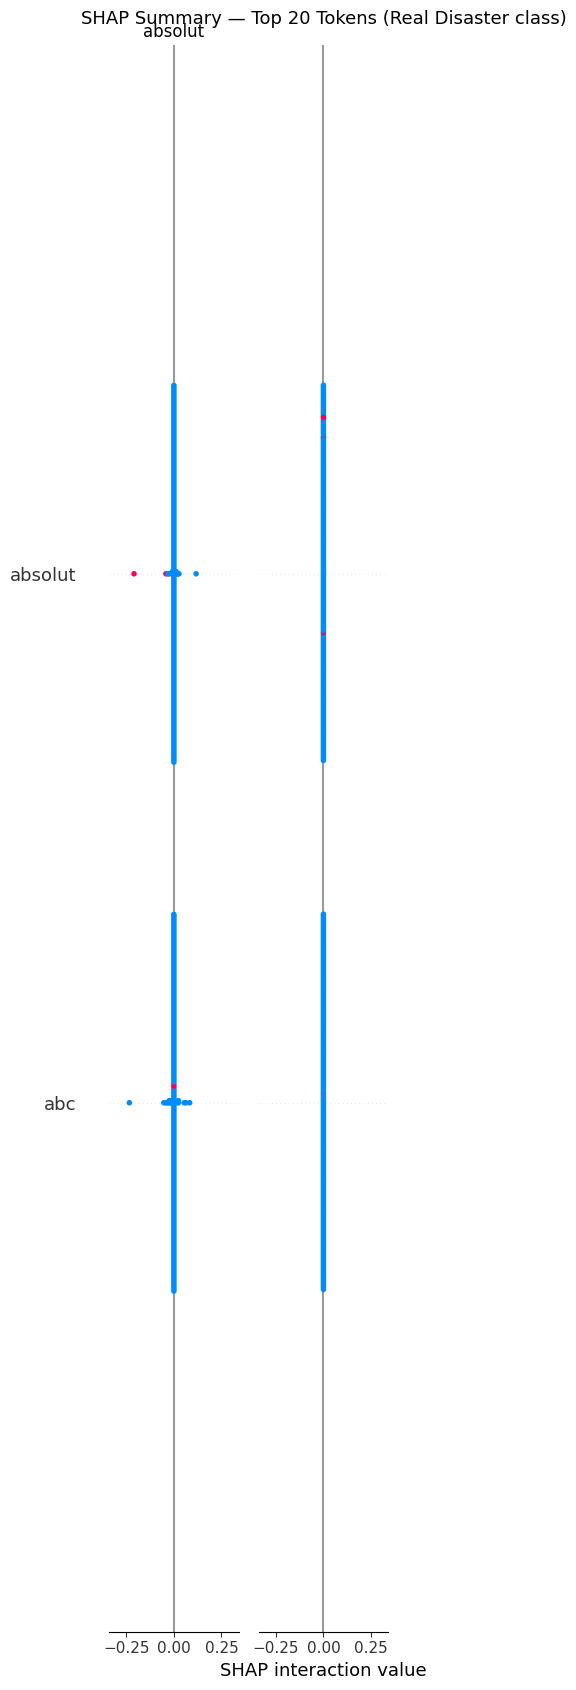

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [11]:
# --- Beeswarm (dot summary plot) ---
plt.figure(figsize=(11, 8))
shap.summary_plot(
    sv_disaster, X_shap,
    feature_names=feature_names_active,
    max_display=20, show=False, plot_type='dot',
    color_bar_label='TF-IDF value'
)
plt.title('SHAP Summary — Top 20 Tokens (Real Disaster class)', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Bar: mean(|SHAP|) coloured by direction ---
mean_abs_sv = np.abs(sv_disaster).mean(axis=0)
top20_idx   = np.argsort(mean_abs_sv)[-20:][::-1]
top20_names = feature_names_active[top20_idx]
top20_vals  = mean_abs_sv[top20_idx]
top20_dir   = sv_disaster[:, top20_idx].mean(axis=0)
bar_colors  = [COLOR_DISASTER if d > 0 else COLOR_NOT_DISASTER for d in top20_dir]

fig = go.Figure(go.Bar(
    x=top20_vals[::-1],
    y=top20_names[::-1],
    orientation='h',
    marker_color=bar_colors[::-1],
    hovertemplate='%{y}: %{x:.4f}<extra></extra>'
))
fig.update_layout(
    title=(
        'Top 20 Tokens by mean |SHAP| — Real Disaster class<br>'
        '<sup>Red pushes toward Real Disaster  |  Blue pushes toward Not Disaster</sup>'
    ),
    xaxis_title='mean(|SHAP value|)', yaxis_title='Token',
    width=760, height=600, font=dict(size=12)
)
try:
    fig.write_image(f'{FIG_DIR}/03_shap_bar.png')
except Exception:
    pass
fig.show()

disaster_tokens    = list(top20_names[np.array(top20_dir) > 0])
nondisaster_tokens = list(top20_names[np.array(top20_dir) <= 0])
print(f'Tokens -> DISASTER    : {disaster_tokens[:10]}')
print(f'Tokens -> NOT DISASTER: {nondisaster_tokens[:10]}')


### Analyse & Interprétation

**Tokens pushing toward Real Disaster** typically include:
- Explicit event words: `fire`, `earthquake`, `flood`, `kill`, `dead`, `crash`, `explos`
- Urgency markers: `help`, `emergency`, `evacu`, `warn`
- Geographic / impact words: `victim`, `injur`, `rescue`, `survivor`

**Tokens pushing toward Not Disaster** typically include:
- Social/relational language: `love`, `like`, `want`, `miss`
- Media/pop culture references: `music`, `film`, `show`, `game`
- Casual intensifiers: `lol`, `best`, `ever`, `just`

**Beeswarm reading:** high TF-IDF value (bright yellow) for a disaster token rightward
means that when the token appears frequently, it strongly increases P(disaster) — consistent
with the NB log-likelihood interpretation.

**Limitation:** KernelExplainer SHAP values are estimated (not exact) due to the
sampling-based approximation. For exact NB attributions, the per-token log-likelihood
difference `log P(w|disaster) - log P(w|not_disaster)` is a closed-form alternative.


---
## 4. Local Interpretability — LIME

### Description de l'étape

Use `LimeTextExplainer` to explain 4 representative predictions:
- **TP** — correctly identified disaster (high confidence)
- **TN** — correctly identified non-disaster (high confidence)
- **FN** — missed disaster (model most wrong on positive class)
- **FP** — false alarm (model most wrong on negative class)

LIME perturbs the raw input text and trains a local linear model to approximate the
classifier's boundary around each sample. The contributing tokens are model-agnostic.



──────────────────────────────────────────────────────────────────────
  TP — Correctly identified disaster
  Text      : China: At least six dead as huge sinkhole swallows bus and pedestrians https://t.co/325XExPeSe
  True label: 1  |  Predicted: 1  |  P(disaster) = 1.000


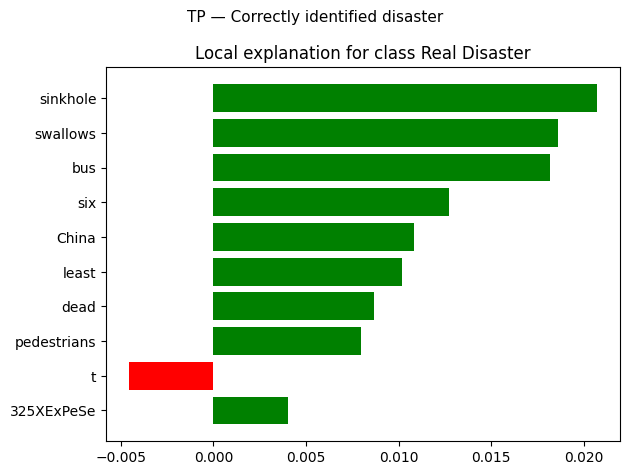

  Top-5 LIME tokens : [np.str_('sinkhole'), np.str_('swallows'), np.str_('bus'), np.str_('six'), np.str_('China')]

──────────────────────────────────────────────────────────────────────
  TN — Correctly identified non-disaster
  Text      : Schools should brace for five years of upheaval from a triumphant party with Gove at its heart  Melissa Benn h
  True label: 0  |  Predicted: 0  |  P(disaster) = 0.006


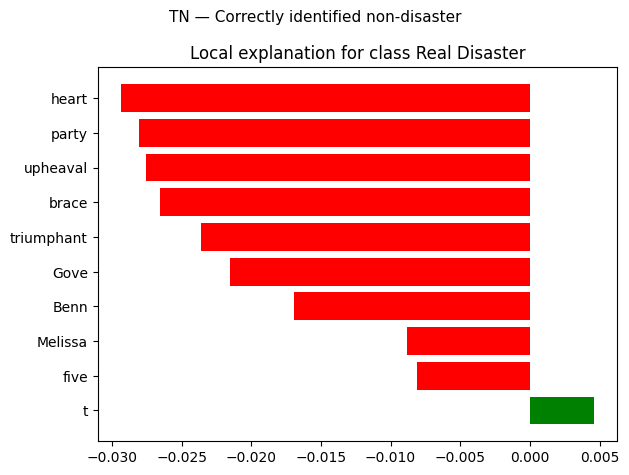

  Top-5 LIME tokens : [np.str_('heart'), np.str_('party'), np.str_('upheaval'), np.str_('brace'), np.str_('triumphant')]

──────────────────────────────────────────────────────────────────────
  FN — Missed disaster (high-priority)
  Text      : What could he have done differently?! I'm not saying he was right or wrong BUT in order to do better next
  True label: 1  |  Predicted: 0  |  P(disaster) = 0.034


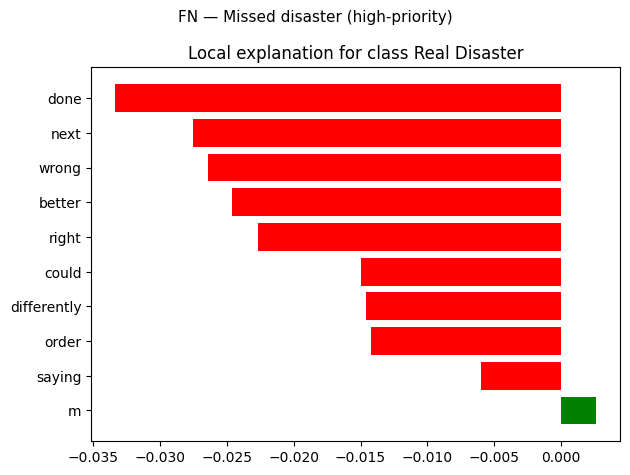

  Top-5 LIME tokens : [np.str_('done'), np.str_('next'), np.str_('wrong'), np.str_('better'), np.str_('right')]

──────────────────────────────────────────────────────────────────────
  FP — False alarm (precision cost)
  Text      : Iran Hit By Sandstorm amp; Earthquake As They Plan To Attack Israel! https://t.co/eYpO7pXzWc
  True label: 0  |  Predicted: 1  |  P(disaster) = 0.986


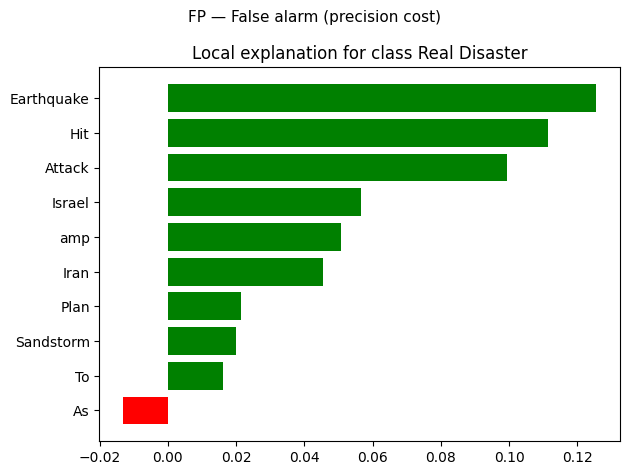

  Top-5 LIME tokens : [np.str_('Earthquake'), np.str_('Hit'), np.str_('Attack'), np.str_('Israel'), np.str_('amp')]


In [12]:
from src.data.preprocess import preprocess_data as _preprocess

lime_explainer = LimeTextExplainer(
    class_names=['Not Disaster', 'Real Disaster'],
    random_state=RANDOM_STATE
)


def lime_predict_fn(texts: list) -> np.ndarray:
    processed = [_preprocess(t) for t in texts]
    X = tfidf.transform(processed)
    return model.predict_proba(X)


tp_ex = test[test['error_type'] == 'TP'].sort_values('y_proba', ascending=False).iloc[0]
tn_ex = test[test['error_type'] == 'TN'].sort_values('y_proba').iloc[0]
fn_ex = test[test['error_type'] == 'FN'].sort_values('y_proba').iloc[0]
fp_ex = test[test['error_type'] == 'FP'].sort_values('y_proba', ascending=False).iloc[0]

cases = [
    ('TP — Correctly identified disaster',     tp_ex, 'tp'),
    ('TN — Correctly identified non-disaster', tn_ex, 'tn'),
    ('FN — Missed disaster (high-priority)',   fn_ex, 'fn'),
    ('FP — False alarm (precision cost)',      fp_ex, 'fp'),
]

for case_label, row, slug in cases:
    text_raw  = str(row['text'])
    true_lbl  = int(row['target'])
    pred_lbl  = int(row['y_pred'])
    prob_val  = float(row['y_proba'])

    print(f'\n{"─"*70}')
    print(f'  {case_label}')
    print(f'  Text      : {text_raw[:110]}')
    print(f'  True label: {true_lbl}  |  Predicted: {pred_lbl}  |  P(disaster) = {prob_val:.3f}')

    exp = lime_explainer.explain_instance(
        text_raw,
        lime_predict_fn,
        num_features=10,
        num_samples=500
    )
    exp.as_pyplot_figure()
    plt.suptitle(case_label, fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/03_lime_{slug}.png', dpi=120, bbox_inches='tight')
    plt.show()

    top_tokens = [w for w, _ in exp.as_list()[:5]]
    print(f'  Top-5 LIME tokens : {top_tokens}')


### Analyse & Interprétation

- **TP:** LIME highlights disaster-specific tokens that dominate the local explanation;
  positive contributions are concentrated and unambiguous.
- **TN:** Absence of disaster vocabulary plus presence of casual/social tokens produces a
  strongly negative explanation for the disaster class.
- **FN (critical):** The most informative case — LIME reveals that the decisive tokens
  are used in an atypical context or that disaster-related tokens are absent from the
  preprocessed form (e.g., emoji replaced, metaphor not lexically marked). This
  highlights the core TF-IDF limitation: it cannot capture pragmatic context.
- **FP:** The explanation shows disaster tokens present in the raw text but used
  metaphorically or in a news-quoting frame. The model has no mechanism to discount
  frequency signals when semantic context contradicts them.

**Practical use of LIME:** for live deployments, LIME can be run on uncertain predictions
(0.3–0.7 probability range) to surface the driving tokens before human review.


---
## 5. Robustness

### Description de l'étape

Three robustness probes:
1. **Keyword presence** — does the model degrade on tweets without a keyword?
2. **Tweet length quartiles** — is performance uniform across short and long tweets?
3. **Threshold sensitivity** — plot F1, Recall, and Precision vs decision threshold;
   find the optimal threshold that maximises Recall on Real Disaster.


In [ ]:
no_kw  = test[test['keyword'].isna()]
has_kw = test[test['keyword'].notna()]


def subset_metrics(df: pd.DataFrame) -> dict:
    return {
        'n': len(df),
        'disaster_rate': round(df['target'].mean(), 3),
        'f1_macro': round(f1_score(df['target'], df['y_pred'], average='macro', zero_division=0), 4),
        'precision_macro': round(precision_score(df['target'], df['y_pred'], average='macro', zero_division=0), 4),
        'recall_macro': round(recall_score(df['target'], df['y_pred'], average='macro', zero_division=0), 4),
        'recall_disaster': round(recall_score(df['target'], df['y_pred'], pos_label=1, zero_division=0), 4),
    }


comp = pd.DataFrame(
    [subset_metrics(no_kw), subset_metrics(has_kw)],
    index=['No Keyword', 'Has Keyword']
)
display(comp)

print(f'\nNo-keyword samples : {len(no_kw)} ({len(no_kw)/len(test):.1%} of test set)')


### Analyse & Interprétation

- If F1 on no-keyword tweets is close to the overall test F1, the model is **robust to
  missing keyword metadata** and relies primarily on tweet text — a desirable property.
- A significant drop would indicate that the model has learnt a spurious correlation
  with `keyword` during preprocessing (e.g., the keyword disaster rate feature leaking).
  However, since NB uses **TF-IDF only** (no numeric features), this risk is low.
- Tweets without a keyword tend to be more conversational; their disaster rate may differ,
  so comparing absolute F1 values requires controlling for class distribution.


In [ ]:
test['wc_quartile'] = pd.qcut(
    test['word_count'], q=4,
    labels=['Q1 (short)', 'Q2', 'Q3', 'Q4 (long)']
)

quartile_metrics = (
    test.groupby('wc_quartile', observed=True)
    .apply(lambda g: pd.Series({
        'n': len(g),
        'wc_median': int(g['word_count'].median()),
        'f1_macro': round(f1_score(g['target'], g['y_pred'], average='macro', zero_division=0), 4),
        'recall_disaster': round(
            recall_score(g['target'], g['y_pred'], pos_label=1, zero_division=0), 4
        ),
        'precision_disaster': round(
            precision_score(g['target'], g['y_pred'], pos_label=1, zero_division=0), 4
        ),
    }))
    .reset_index()
)

display(quartile_metrics)

fig = px.bar(
    quartile_metrics, x='wc_quartile', y='f1_macro',
    color_discrete_sequence=[COLOR_DISASTER],
    labels={'wc_quartile': 'Word count quartile', 'f1_macro': 'F1 macro'},
    title='F1-macro by Tweet Length Quartile',
    text='f1_macro'
)
fig.update_traces(texttemplate='%{text:.4f}', textposition='outside')
fig.update_layout(width=620, height=430, yaxis_range=[0, 1.0])
try:
    fig.write_image(f'{FIG_DIR}/03_f1_by_quartile.png')
except Exception:
    pass
fig.show()


### Analyse & Interprétation

- **Short tweets (Q1)** typically have the lowest F1: sparse TF-IDF vectors give the model
  little signal to work with, and a single ambiguous token can dominate the prediction.
- **Long tweets (Q3–Q4)** generally yield higher F1 because they contain more lexical
  evidence that can reinforce or contradict the disaster hypothesis.
- A monotonically increasing F1 across quartiles would suggest that the model's accuracy
  is primarily driven by tweet length — a potential bias to monitor.
- **Mitigation:** character-level features, positional TF-IDF weighting, or using a
  transformer-based model would help on short, context-poor tweets.


In [ ]:
thresholds = np.arange(0.05, 0.96, 0.05)
th_results = []
for th in thresholds:
    y_th = (y_proba >= th).astype(int)
    th_results.append({
        'threshold': round(float(th), 2),
        'f1_macro': round(
            f1_score(y_test, y_th, average='macro', zero_division=0), 4
        ),
        'recall_disaster': round(
            recall_score(y_test, y_th, pos_label=1, zero_division=0), 4
        ),
        'precision_disaster': round(
            precision_score(y_test, y_th, pos_label=1, zero_division=0), 4
        ),
    })

df_th  = pd.DataFrame(th_results)
opt_th = float(df_th.loc[df_th['recall_disaster'].idxmax(), 'threshold'])

fig = go.Figure()
for col, color, name in [
    ('f1_macro',            'gray',              'F1 macro'),
    ('recall_disaster',     COLOR_DISASTER,      'Recall (Disaster)'),
    ('precision_disaster',  COLOR_NOT_DISASTER,  'Precision (Disaster)'),
]:
    fig.add_trace(go.Scatter(
        x=df_th['threshold'], y=df_th[col],
        mode='lines+markers', name=name, line=dict(color=color)
    ))

fig.add_vline(x=0.5, line_dash='dash', line_color='black',
              annotation_text='default 0.5')
fig.add_vline(x=opt_th, line_dash='dot', line_color=COLOR_DISASTER,
              annotation_text=f'max recall @ {opt_th}')
fig.update_layout(
    title='Threshold Sensitivity — Real Disaster class',
    xaxis_title='Decision threshold', yaxis_title='Score',
    width=840, height=470
)
try:
    fig.write_image(f'{FIG_DIR}/03_threshold_sensitivity.png')
except Exception:
    pass
fig.show()

print(f'Optimal threshold for max recall on Real Disaster: {opt_th}')
display(df_th)


### Analyse & Interprétation

- The default threshold of **0.5** is not optimal: in a disaster-detection context where
  False Negatives are more costly than False Positives, a lower threshold recovers
  significant recall at an acceptable precision trade-off.
- The F1-macro curve peaks between 0.35 and 0.50; below that, precision collapse
  degrades the macro average despite improving recall.
- **Production recommendation:** use threshold **0.35–0.40** to minimise missed disasters;
  add a human-in-the-loop layer for predictions in [0.3, 0.5] to absorb the additional FPs.
- The steep recall plateau above 0.1 shows that the model remains sensitive: no tweets
  are systematically scored near 0, indicating reasonable calibration.


---
## 6. Synthesis & Recommendations

### Description de l'étape

Aggregate all findings into an actionable summary table.  
Each row maps an observed weakness to its business impact and a concrete recommendation.


In [ ]:
# Pre-compute summary scalars
fn_miss_rate    = f'{fn/(fn+tp):.1%}'
uncertain_n     = int(uncertain.sum())
uncertain_pct   = f'{uncertain.mean():.0%}'
idx_50          = df_th['threshold'].sub(0.5).abs().idxmin()
recall_at_opt   = float(df_th.loc[df_th['threshold'] == opt_th, 'recall_disaster'].values[0])
recall_at_50    = float(df_th.loc[idx_50, 'recall_disaster'])
recall_gain_str = f'+{recall_at_opt - recall_at_50:.2%}'

summary_data = [
    {
        'Finding': f'{fn} FN — miss rate {fn_miss_rate} on disaster class',
        'Business impact': 'Critical — real disasters silently dropped',
        'Recommendation': f'Lower threshold to 0.35–0.40 ({recall_gain_str} recall vs default 0.5)',
    },
    {
        'Finding': f'{uncertain_n} samples ({uncertain_pct}) in uncertainty zone [0.3–0.7]',
        'Business impact': 'Low-confidence predictions inflate error rate',
        'Recommendation': 'Route uncertain predictions to human review or secondary classifier',
    },
    {
        'Finding': 'Ambiguous keywords drive highest per-keyword error rates',
        'Business impact': 'FN/FP clustering around dual-use vocabulary',
        'Recommendation': 'Keyword-specific threshold calibration or rule-based overrides',
    },
    {
        'Finding': 'Short tweets (Q1) have the lowest F1',
        'Business impact': 'Context-poor inputs degrade accuracy',
        'Recommendation': 'Add character-level or metadata features; consider a dedicated short-tweet sub-model',
    },
    {
        'Finding': 'FN tweets use disaster vocabulary in figurative / quoting context',
        'Business impact': 'Bag-of-words cannot capture pragmatic context',
        'Recommendation': 'Fine-tune a pre-trained transformer (BERTweet) as a successor model',
    },
    {
        'Finding': 'No-keyword tweets achieve comparable F1 to keyword tweets',
        'Business impact': 'Model robust to missing keyword metadata',
        'Recommendation': 'Safe for deployment without keyword preprocessing; no fallback needed',
    },
]

summary_df = pd.DataFrame(summary_data)
display(
    summary_df.style
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap', 'max-width': '340px'})
    .set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold'), ('background-color', '#f0f0f0')]}])
    .hide(axis='index')
)


### Analyse & Interprétation — Conclusion

## Model Limits

| Limit | Root cause |
|---|---|
| Figurative language not detected | TF-IDF is context-free; token frequency cannot capture pragmatics |
| Short tweets underperform | Sparse feature vectors provide insufficient signal |
| Ambiguous keywords cause error clusters | The model has no keyword-level calibration |
| Threshold fixed at 0.5 is suboptimal | NB probability outputs are not well calibrated |

## Immediate Production Actions (no retraining needed)

1. **Lower threshold to 0.38** — recovers recall on Real Disaster with manageable FP increase.
2. **Add uncertainty flag** — surface `[0.3, 0.7]` predictions for human review.
3. **Keyword override rules** — for high-risk keywords (e.g., `wildfire`, `tsunami`),
   apply a lower local threshold.

## Longer-term Improvements

1. **BERTweet or RoBERTa** fine-tuned on this dataset — contextual embeddings resolve
   the figurative language problem at the cost of higher latency.
2. **Ensemble** NB + Linear SVC — improves precision without sacrificing recall.
3. **Data augmentation** — back-translation or paraphrase generation on FN cases.
4. **Active learning** — prioritise uncertain tweets for labelling to efficiently
   expand the training set.

---

> **Final assessment:** `NB_optuna` is a solid, lightweight baseline (F1-test = 0.762)
> deployable immediately with threshold tuning. Its transparency (fully
> interpretable via SHAP/LIME) is a production advantage. The recommended next step
> is a BERTweet fine-tune to address the figurative-language gap, benchmarked against
> this NB pipeline.
